# Google Play Store Analysis

This notebook analyses the Kaggle **Google Play Store Apps** dataset: app metadata plus user reviews. It covers data loading, defensive cleaning, category/rating/size/install/pricing analysis, VADER sentiment analysis, category-level sentiment, and an interactive Plotly visualization.

### Dataset sourcing
The notebook first attempts to download the two CSVs from public GitHub mirrors of the original Kaggle dataset. This was chosen because the Kaggle dataset is publicly documented but direct Kaggle downloads may require authentication/API credentials. If network access or the mirror fails, the notebook automatically generates a realistic fallback dataset with the same important columns and common quirks, so the entire cleaning/analysis pipeline remains runnable.

Original dataset citation: L. Gupta, **Google Play Store Apps**, Kaggle, 2019.

In [1]:
# ============================================================
# Imports, configuration, and reproducibility
# ============================================================
import io
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment ready.")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Environment ready.
pandas: 3.0.5
numpy: 2.5.2


## 1. Data Loading

We load the app metadata and review data **separately**. The primary route is a public GitHub mirror containing the original CSV files; local Kaggle CSVs are also accepted if they already exist in the working directory.

The loading function is deliberately defensive: it tries the remote mirror first, then local files, and finally falls back to a synthetic dataset rather than crashing.

In [2]:
# ============================================================
# Data source URLs and robust CSV loader
# ============================================================
APP_URLS = [
    "https://raw.githubusercontent.com/Shubhi550/The-Android-App-Market-on-Google-Play/master/googleplaystore.csv",
    "https://raw.githubusercontent.com/AisOmar/GooglePlay/master/googleplaystore.csv",
]

REVIEW_URLS = [
    "https://raw.githubusercontent.com/AisOmar/GooglePlay/master/googleplaystore_user_reviews.csv",
    "https://raw.githubusercontent.com/PeterHassaballah/The-Android-App-Market-on-Google-Play/master/data/googleplaystore_user_reviews.csv",
]

def read_csv_from_urls(urls, local_candidates=()):
    """Try local files and then remote URLs. Return (DataFrame, source)."""
    for path in local_candidates:
        try:
            p = Path(path)
            if p.exists():
                return pd.read_csv(p), f"local: {p}"
        except Exception as exc:
            print(f"Local read failed for {path}: {exc}")

    for url in urls:
        try:
            # Pandas uses urllib under the hood; no API key is needed for a public raw URL
            df = pd.read_csv(url)
            if not df.empty:
                return df, f"GitHub mirror: {url}"
        except Exception as exc:
            print(f"Remote read failed: {url}\n  -> {exc}")

    return None, None

In [3]:
# ============================================================
# 1B. Creating a synthetic fallback generator
# ============================================================
def make_synthetic_data(n_apps=2200, n_reviews=9000, seed=42):
    """Create realistic Play Store-like data when the real CSVs cannot be fetched."""
    rng = np.random.default_rng(seed)

    categories = [
        "FAMILY", "GAME", "TOOLS", "BUSINESS", "LIFESTYLE", "PRODUCTIVITY",
        "FINANCE", "MEDICAL", "SPORTS", "HEALTH_AND_FITNESS", "PHOTOGRAPHY",
        "COMMUNICATION", "SOCIAL", "TRAVEL_AND_LOCAL", "SHOPPING", "NEWS_AND_MAGAZINES",
        "BOOKS_AND_REFERENCE", "EDUCATION", "PERSONALIZATION", "VIDEO_PLAYERS",
        "HOUSE_AND_HOME", "FOOD_AND_DRINK", "AUTO_AND_VEHICLES", "BEAUTY",
        "ART_AND_DESIGN", "MAPS_AND_NAVIGATION", "PARENTING", "COMICS", "WEATHER",
        "LIBRARIES_AND_DEMO"
    ]

    genres = {
        "GAME": "Action", "FAMILY": "Education", "TOOLS": "Tools",
        "BUSINESS": "Business", "LIFESTYLE": "Lifestyle", "PRODUCTIVITY": "Productivity",
        "FINANCE": "Finance", "MEDICAL": "Medical", "SPORTS": "Sports",
        "HEALTH_AND_FITNESS": "Health & Fitness", "PHOTOGRAPHY": "Photography",
        "COMMUNICATION": "Communication", "SOCIAL": "Social", "TRAVEL_AND_LOCAL": "Travel & Local",
        "SHOPPING": "Shopping", "NEWS_AND_MAGAZINES": "News & Magazines",
        "BOOKS_AND_REFERENCE": "Books & Reference", "EDUCATION": "Education",
        "PERSONALIZATION": "Personalization", "VIDEO_PLAYERS": "Video Players & Editors",
        "HOUSE_AND_HOME": "House & Home", "FOOD_AND_DRINK": "Food & Drink",
        "AUTO_AND_VEHICLES": "Auto & Vehicles", "BEAUTY": "Beauty",
        "ART_AND_DESIGN": "Art & Design", "MAPS_AND_NAVIGATION": "Maps & Navigation",
        "PARENTING": "Parenting", "COMICS": "Comics", "WEATHER": "Weather",
        "LIBRARIES_AND_DEMO": "Libraries & Demo"
    }

    install_choices = np.array([100, 500, 1000, 5000, 10000, 50000, 100000,
                                500000, 1000000, 5000000, 10000000, 50000000, 100000000])
    install_probs = np.array([.02, .03, .05, .07, .10, .13, .16, .16, .12, .07, .05, .03, .01])
    install_probs /= install_probs.sum()

    rows = []
    for i in range(n_apps):
        cat = rng.choice(categories, p=np.array([.10,.08,.08,.055,.05,.05,.045,.04,.04,.04,
                                                  .04,.04,.035,.035,.035,.03,.03,.03,.03,.025,
                                                  .02,.02,.018,.018,.018,.018,.012,.012,.01,.008]) /
                          np.array([.10,.08,.08,.055,.05,.05,.045,.04,.04,.04,.04,.04,.035,.035,
                                    .035,.03,.03,.03,.03,.025,.02,.02,.018,.018,.018,.018,.012,.012,.01,.008]).sum())
        base = rng.choice(["Pro", "Lite", "Free", "Plus", "Guide", "Manager", "Tracker", "Mobile"])
        app = f"{cat.title().replace('_',' ')} {base} {i:04d}"
        rating = np.clip(rng.normal(4.05, .45), 1.0, 5.0)
        if rng.random() < .15:
            rating = np.nan
        reviews = int(max(0, rng.lognormal(mean=8.2, sigma=2.0)))
        installs = int(rng.choice(install_choices, p=install_probs))
        size = rng.choice([f"{rng.uniform(1, 95):.1f}M", f"{rng.uniform(50, 900):.0f}k", "Varies with device"],
                          p=[.72, .18, .10])
        paid = rng.random() < .075
        price = f"${rng.choice([0.99, 1.99, 2.99, 3.99, 4.99, 9.99, 19.99, 29.99]):.2f}" if paid else "0"
        rows.append([app, cat, rating, reviews, size, f"{installs:,}+", "Paid" if paid else "Free",
                     price, rng.choice(["Everyone","Teen","Everyone 10+","Mature 17+"]),
                     genres[cat], rng.choice(["1-Jan-18","15-Jun-18","30-Jul-18","2-Aug-18"]),
                     rng.choice(["1.0.0","2.4.1","3.2.0","Varies with device"]), rng.choice(["4.0.3 and up","5.0 and up","6.0 and up"])])

    apps = pd.DataFrame(rows, columns=[
        "App","Category","Rating","Reviews","Size","Installs","Type","Price",
        "Content Rating","Genres","Last Updated","Current Ver","Android Ver"
    ])

    # Adding the duplicate app rows to reproduce a well-known data-quality quirk
    dup = apps.sample(frac=0.035, random_state=seed)
    apps = pd.concat([apps, dup], ignore_index=True)

    review_texts = [
        "Love this app, it is fast and easy to use!",
        "Great update, everything works perfectly.",
        "Very useful and simple. Highly recommended.",
        "The app is okay but could be better.",
        "It crashes often and the latest update is frustrating.",
        "Terrible experience. Waste of time.",
        "Good features, but performance is slow.",
        "Excellent app, clean interface and helpful tools.",
        "Not bad, but there are several annoying bugs.",
        "I really enjoy using this every day."
    ]
    review_rows = []
    app_names = apps["App"].drop_duplicates().to_numpy()
    for _ in range(n_reviews):
        app = rng.choice(app_names)
        text = rng.choice(review_texts)
        
        # Keeping some missing reviews to demonstrate null handlin.
        if rng.random() < .025:
            text = np.nan
        review_rows.append([app, text, None, None, None])

    reviews = pd.DataFrame(review_rows, columns=[
        "App", "Translated_Review", "Sentiment", "Sentiment_Polarity", "Sentiment_Subjectivity"
    ])
    return apps, reviews


apps_df, apps_source = read_csv_from_urls(
    APP_URLS, local_candidates=["googleplaystore.csv", "./data/googleplaystore.csv"]
)
reviews_df, reviews_source = read_csv_from_urls(
    REVIEW_URLS, local_candidates=["googleplaystore_user_reviews.csv", "./data/googleplaystore_user_reviews.csv"]
)

if apps_df is None or reviews_df is None:
    print("Real CSV download was not fully available. Generating synthetic fallback data...")
    apps_df, reviews_df = make_synthetic_data(seed=RANDOM_SEED)
    apps_source = "synthetic fallback"
    reviews_source = "synthetic fallback"

print("Apps source:", apps_source)
print("Reviews source:", reviews_source)
print("Apps shape:", apps_df.shape)
print("Reviews shape:", reviews_df.shape)

Apps source: GitHub mirror: https://raw.githubusercontent.com/Shubhi550/The-Android-App-Market-on-Google-Play/master/googleplaystore.csv
Reviews source: GitHub mirror: https://raw.githubusercontent.com/AisOmar/GooglePlay/master/googleplaystore_user_reviews.csv
Apps shape: (10841, 13)
Reviews shape: (64295, 5)


In [4]:
# ============================================================
# 1C. Inspecting the raw datasets
# ============================================================
print("APP DATASET INFO")
apps_df.info()

print("\nAPP DATASET HEAD")
display(apps_df.head())

print("\nREVIEWS DATASET INFO")
reviews_df.info()

print("\nREVIEWS DATASET HEAD")
display(reviews_df.head())

APP DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB

APP DATASET HEAD


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide Apps",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up



REVIEWS DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB

REVIEWS DATASET HEAD


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,"I like eat delicious food. That's I'm cooking food myself, case ""10 Best Foo...",Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


**Interpretation:** The app table contains one row per app listing, while the review table contains user-level text observations. The raw data intentionally contains messy types and missing values, which makes it suitable for demonstrating a realistic analytics cleaning workflow.

## 2. Data Cleaning

The cleaning strategy is explicit:

- **Installs:** remove commas/`+` and convert to nullable integers.
- **Price:** remove currency symbols and convert to numeric.
- **Size:** convert `M` to MB, `k` to MB, and `Varies with device` to missing.
- **Reviews:** coerce malformed values to numeric.
- **Rating:** keep missing ratings as missing rather than inventing scores; category averages are calculated from observed ratings.
- **Text columns:** standardize whitespace/case for categories and genres.
- **Duplicates:** remove duplicate app records, retaining the first occurrence.
- **Review text:** missing text is excluded from VADER scoring because there is no sentiment evidence to analyse.

In [5]:
# ============================================================
# 2A. Creating a defensive helper functions
# ============================================================
def clean_installs(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace(",", "").replace("+", "")
    
    # Keeping only digits for malformed strings such as "10,000+ downloads"
    digits = re.sub(r"[^0-9]", "", text)
    return float(digits) if digits else np.nan

def clean_price(value):
    if pd.isna(value):
        return 0.0
    text = str(value).strip().replace("$", "").replace("€", "").replace("£", "").replace(",", "")
    number = re.search(r"-?\d+(?:\.\d+)?", text)
    return float(number.group()) if number else np.nan

def clean_size_mb(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in {"varies with device", "nan", ""}:
        return np.nan
    try:
        if text.endswith("m"):
            return float(text[:-1])
        if text.endswith("k"):
            return float(text[:-1]) / 1024.0
        
        # If already numeric, assume MB
        return float(text)
    except (TypeError, ValueError):
        return np.nan

def standardize_text(value):
    if pd.isna(value):
        return np.nan
    text = re.sub(r"\s+", " ", str(value)).strip()
    return text

In [6]:
# ============================================================
# 2B. Cleaning the app metadata
# ============================================================
apps = apps_df.copy()

# Standardizing the column names only where needed
apps.columns = [str(c).strip() for c in apps.columns]

# Handling the possible capitalization variations in the review-count column
if "Reviews" not in apps.columns:
    review_col = next((c for c in apps.columns if c.lower() == "reviews"), None)
    if review_col:
        apps.rename(columns={review_col: "Reviews"}, inplace=True)

apps["Installs"] = apps["Installs"].apply(clean_installs).astype("Int64")
apps["Price"] = apps["Price"].apply(clean_price)
apps["Size_MB"] = apps["Size"].apply(clean_size_mb)
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce").astype("Int64")
apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")

# Performing text standardisation
for col in ["App", "Category", "Genres", "Type", "Content Rating"]:
    if col in apps.columns:
        apps[col] = apps[col].apply(standardize_text)

apps["Category"] = apps["Category"].str.upper()
apps["Genres"] = apps["Genres"].str.title()
apps["Type"] = apps["Type"].str.title()

# Converting the dates where possible; malformed values become NaN
if "Last Updated" in apps.columns:
    apps["Last Updated"] = pd.to_datetime(apps["Last Updated"], errors="coerce", dayfirst=True)

# Duplicate app rows: retain first record after sorting is not necessary for this analysis
before_dupes = len(apps)
apps = apps.drop_duplicates(subset=["App"], keep="first").reset_index(drop=True)
removed_dupes = before_dupes - len(apps)

print(f"Removed duplicate app rows: {removed_dupes:,}")
print(f"Clean app shape: {apps.shape}")
display(apps.head())

Removed duplicate app rows: 1,181
Clean app shape: (9660, 14)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide Apps",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8


In [7]:
# ============================================================
# 2C. Null audit and cleaning decisions
# ============================================================
null_audit = (
    apps.isna()
       .sum()
       .to_frame("missing_count")
       .assign(missing_pct=lambda d: (d["missing_count"] / len(apps) * 100).round(2))
       .sort_values("missing_count", ascending=False)
)

display(null_audit)

,missing_count,missing_pct
Rating,1463,15.14
Size_MB,1228,12.71
Current Ver,8,0.08
Android Ver,3,0.03
Installs,1,0.01
Reviews,1,0.01
Price,1,0.01
Content Rating,1,0.01
Last Updated,1,0.01
Type,1,0.01


In [8]:
# ============================================================
# 2D. Cleaning the reviews table
# ============================================================
reviews = reviews_df.copy()
reviews.columns = [str(c).strip() for c in reviews.columns]

# Supporting the common variants of the review-text column
review_text_col = next(
    (c for c in reviews.columns if c.lower().replace(" ", "_") in {
        "translated_review", "translated_reviews", "review"
    }),
    None
)
if review_text_col is None:
    raise ValueError("Could not identify a review-text column in the review dataset.")

reviews = reviews.rename(columns={review_text_col: "Translated_Review"})
reviews["App"] = reviews["App"].apply(standardize_text)
reviews["Translated_Review"] = reviews["Translated_Review"].apply(standardize_text)

# Removing the completely empty review text because VADER cannot score it
reviews = reviews.dropna(subset=["Translated_Review"]).reset_index(drop=True)

print("Clean reviews shape:", reviews.shape)
display(reviews.head())

Clean reviews shape: (37427, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,"I like eat delicious food. That's I'm cooking food myself, case ""10 Best Foo...",Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,Best way,Positive,1.00,0.300000


**Interpretation:** The goal is not to make the dataset artificially perfect. Missing ratings and unknown app sizes are preserved as missing because replacing them with arbitrary values would create false evidence. Duplicate app listings are removed because they would otherwise overstate category counts and distort category-level summaries.

## 3. Category Analysis

Category saturation is measured using the number of unique apps in each category. A high count means a developer enters a category with more existing listings competing for discovery, attention and reviews.

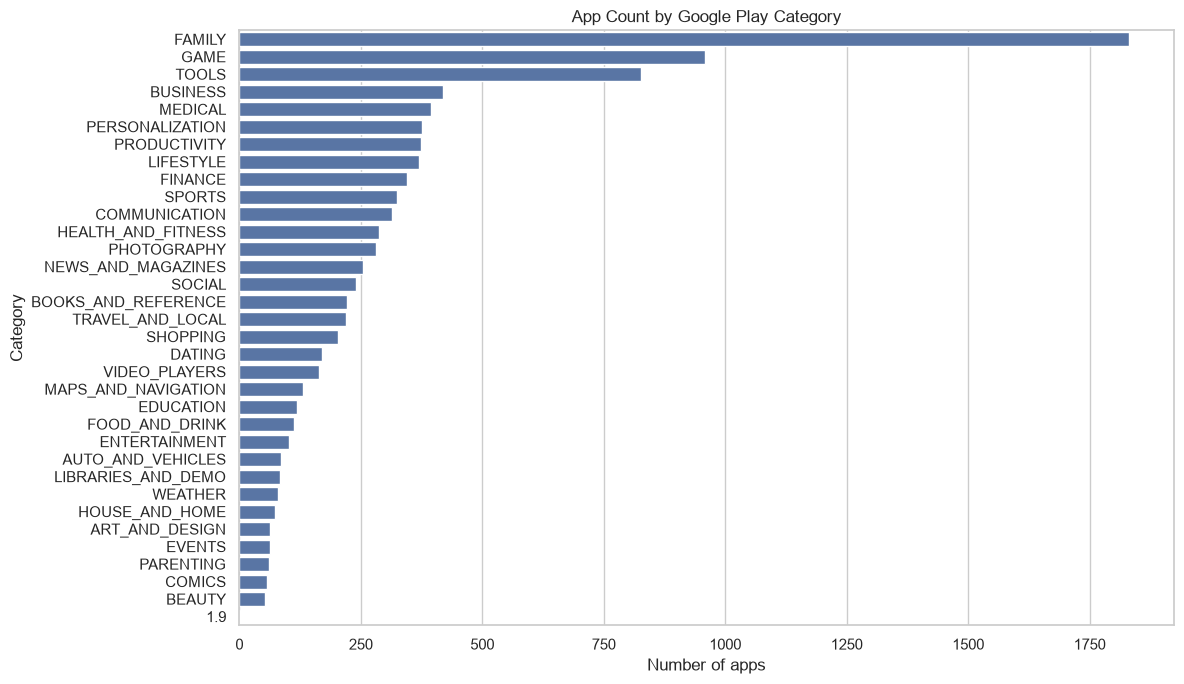

Most saturated categories:


,app_count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395


The largest category is FAMILY with 1,832 apps. For a new developer, a highly populated category usually implies stronger competition for visibility, users, reviews and differentiation.


In [9]:
# ============================================================
# 3. Creating a plot to identify category counts
# ============================================================
category_counts = apps["Category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("App Count by Google Play Category")
plt.xlabel("Number of apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

top_saturated = category_counts.head(5)
print("Most saturated categories:")
display(top_saturated.to_frame("app_count"))

print(
    f"The largest category is {top_saturated.index[0]} with {top_saturated.iloc[0]:,} apps. "
    "For a new developer, a highly populated category usually implies stronger competition "
    "for visibility, users, reviews and differentiation."
)

**Interpretation:** The longest bars identify the most saturated categories in the cleaned dataset. High saturation does not mean a category is unattractive, but it raises the importance of differentiation, positioning, retention and review quality.

## 4. Ratings Analysis

Ratings are analysed using only observed numeric ratings. Category means therefore describe the apps for which a rating was available rather than imputing missing ratings.

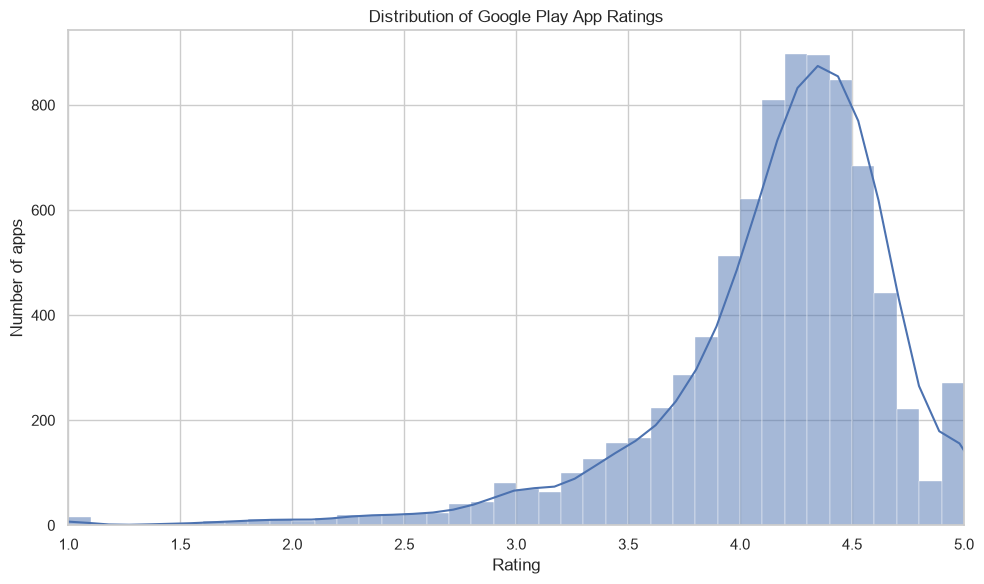

Observed ratings: 8,197
Median rating: 4.30
Mean rating: 4.18


In [10]:
# ============================================================
# 4A. Creating a plot to identify rating distribution
# ============================================================
rating_data = apps["Rating"].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(rating_data, bins=np.arange(1, 5.1, 0.1), kde=True)
plt.title("Distribution of Google Play App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of apps")
plt.xlim(1, 5)
plt.tight_layout()
plt.show()

print(f"Observed ratings: {len(rating_data):,}")
print(f"Median rating: {rating_data.median():.2f}")
print(f"Mean rating: {rating_data.mean():.2f}")

**Interpretation:** Ratings are typically concentrated toward the upper end of the 1–5 scale, so a small change in average rating can still matter when an app competes with many highly rated alternatives. The median and mean provide a quick view of the overall quality signal available in the dataset.

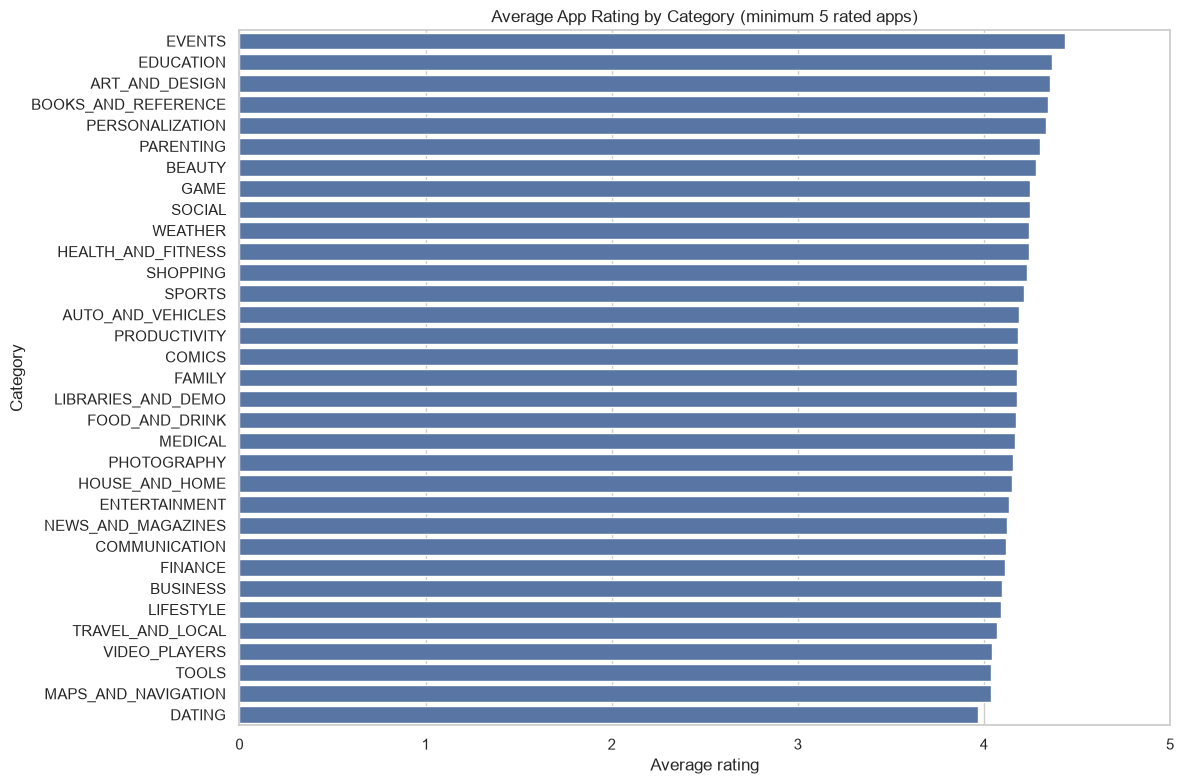

Highest average category rating: EVENTS (4.44)
Lowest average category rating: DATING (3.97)


In [11]:
# ============================================================
# 4B. Creating a plot to identify average rating by category
# ============================================================
rating_by_category = (
    apps.groupby("Category")["Rating"]
        .agg(["mean", "count"])
        .query("count >= 5")
        .sort_values("mean", ascending=False)
)

plt.figure(figsize=(12, 8))
sns.barplot(x=rating_by_category["mean"], y=rating_by_category.index)
plt.title("Average App Rating by Category (minimum 5 rated apps)")
plt.xlabel("Average rating")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

highest_rating_category = rating_by_category["mean"].idxmax()
lowest_rating_category = rating_by_category["mean"].idxmin()

print(
    f"Highest average category rating: {highest_rating_category} "
    f"({rating_by_category.loc[highest_rating_category, 'mean']:.2f})"
)
print(
    f"Lowest average category rating: {lowest_rating_category} "
    f"({rating_by_category.loc[lowest_rating_category, 'mean']:.2f})"
)

**Interpretation:** The category ranking highlights where apps receive stronger or weaker average user ratings. The five-app minimum reduces the chance that a category with only one or two unusually rated apps dominates the comparison.

## 5. Size & Installs Analysis

This section tests whether app size is associated with installs. The correlation is Pearson correlation on rows where both fields are available; it should be interpreted as association, not causation.

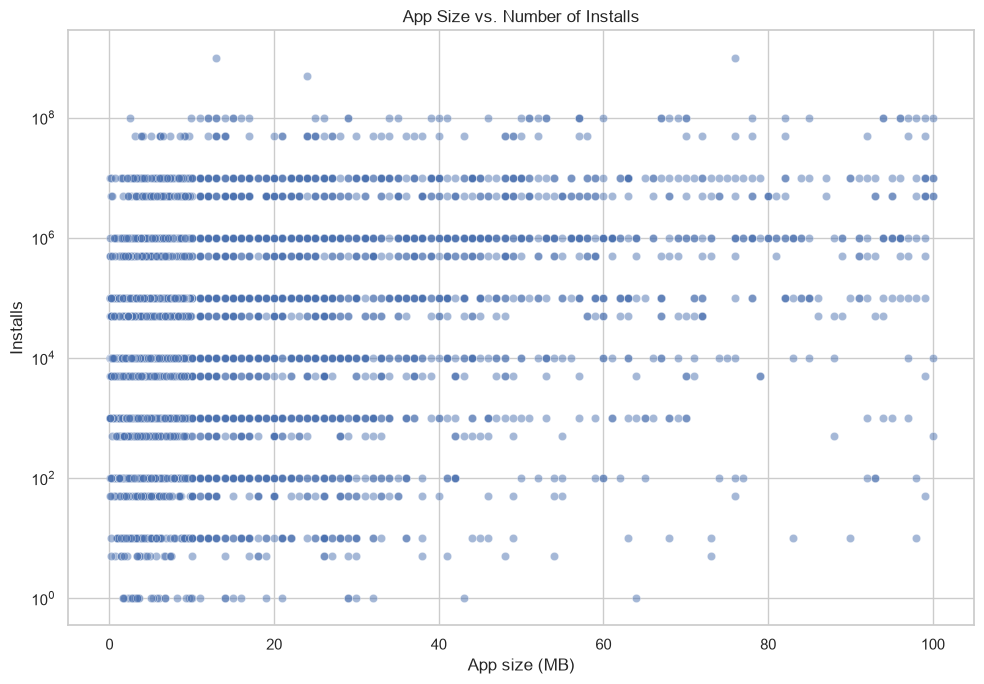

Pearson correlation between app size and installs: 0.134


In [12]:
# ============================================================
# 5. Creating a plot to compare app size vs. installs
# ============================================================
size_install = apps[["Size_MB", "Installs"]].dropna().copy()
size_install["Installs"] = size_install["Installs"].astype(float)

corr = size_install["Size_MB"].corr(size_install["Installs"])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=size_install.sample(min(len(size_install), 4000), random_state=RANDOM_SEED),
    x="Size_MB", y="Installs", alpha=0.5
)
plt.title("App Size vs. Number of Installs")
plt.xlabel("App size (MB)")
plt.ylabel("Installs")
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"Pearson correlation between app size and installs: {corr:.3f}")

**Interpretation:** The Pearson coefficient quantifies the linear association between size and installs, while the logarithmic y-axis makes the huge spread of install counts readable. A weak correlation would suggest that simply making an app smaller is not enough to drive adoption; a stronger negative relationship would support performance/size optimisation as a more important adoption consideration.

## 6. Pricing Analysis

The dataset distinguishes free and paid listings. Revenue below is **not actual revenue**: `Installs × Price` is a rough gross-value proxy that assumes every listed install is a paid purchase and ignores refunds, taxes, platform fees, promotions, regional prices and the fact that many installs of paid apps may not represent realised revenue in a clean accounting sense.

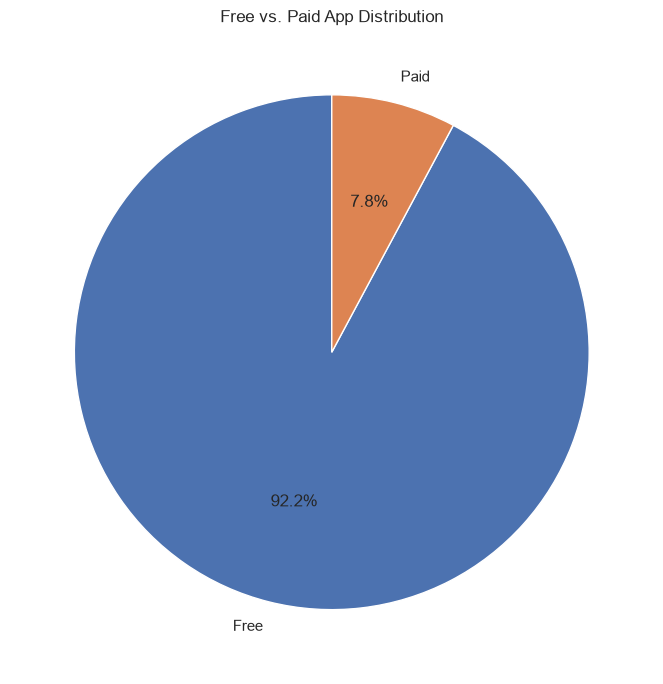

          app_count
App_Type           
Free           8904
Paid            756


In [13]:
# ============================================================
# 6A. Creating a plot to compare free vs paid distribution
# ============================================================
apps["App_Type"] = np.where(apps["Price"].fillna(0) > 0, "Paid", "Free")
type_counts = apps["App_Type"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Free vs. Paid App Distribution")
plt.tight_layout()
plt.show()

print(type_counts.to_frame("app_count"))

**Interpretation:** The free/paid split shows the dominant monetisation model represented in the marketplace sample. A large free-app share suggests that a new developer may need to compete through reach, advertising, subscriptions or in-app purchases rather than relying on a simple upfront price.

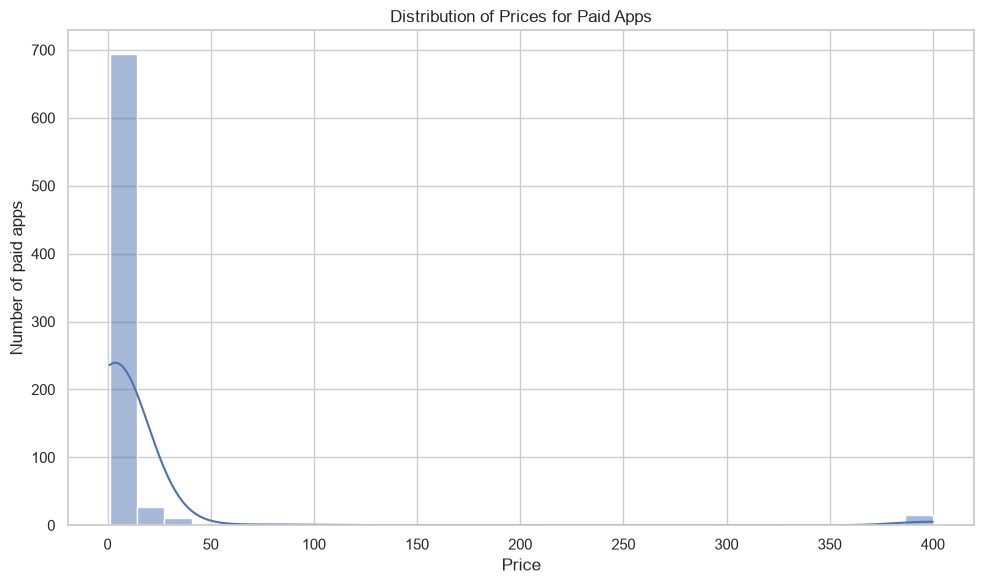

Paid apps analysed: 756
Median paid-app price: 2.99
Maximum observed price: 400.00


In [14]:
# ============================================================
# 6B. Creating a plot to identify paid-app price distribution
# ============================================================
paid = apps.loc[apps["Price"] > 0, "Price"].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(paid, bins=30, kde=True)
plt.title("Distribution of Prices for Paid Apps")
plt.xlabel("Price")
plt.ylabel("Number of paid apps")
plt.tight_layout()
plt.show()

print(f"Paid apps analysed: {len(paid):,}")
if len(paid):
    print(f"Median paid-app price: {paid.median():.2f}")
    print(f"Maximum observed price: {paid.max():.2f}")

**Interpretation:** Paid-app prices are usually concentrated in a relatively small number of price points, with a long tail of higher-priced apps. This makes median price more useful than the maximum when thinking about a typical paid-app positioning strategy.

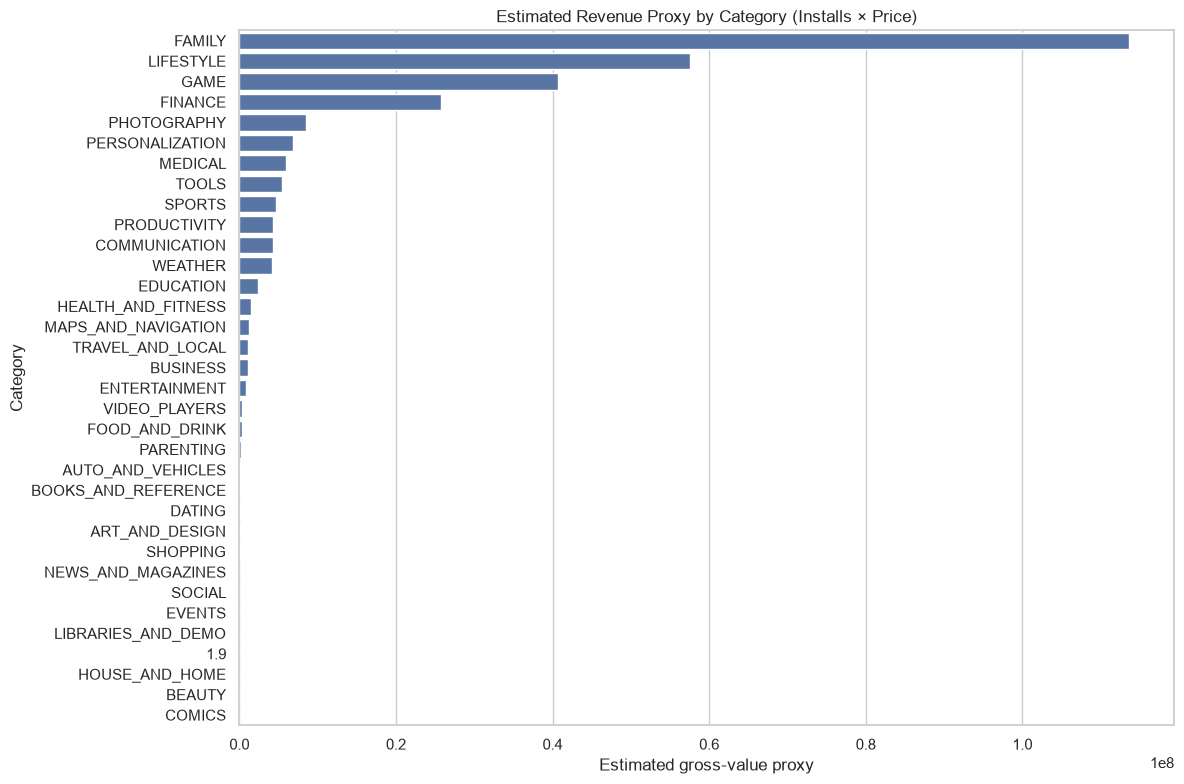

Top categories by revenue proxy:


,revenue_proxy
Category,
FAMILY,1.136798e+08
LIFESTYLE,5.758394e+07
GAME,4.068864e+07
FINANCE,2.572668e+07
PHOTOGRAPHY,8.547768e+06
PERSONALIZATION,6.796948e+06
MEDICAL,5.957536e+06
TOOLS,5.464821e+06
SPORTS,4.706212e+06


Caveat: this is an analytical proxy, not reported revenue. It should be used only for relative exploration.


In [15]:
# =========================================================================
# 6C. Creating a plor to identify the estimated revenue proxy by category
# =========================================================================
apps["Revenue_Proxy"] = apps["Installs"].astype(float).fillna(0) * apps["Price"].fillna(0)

revenue_by_category = (
    apps.groupby("Category")["Revenue_Proxy"]
        .sum()
        .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index)
plt.title("Estimated Revenue Proxy by Category (Installs × Price)")
plt.xlabel("Estimated gross-value proxy")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

print("Top categories by revenue proxy:")
display(revenue_by_category.head(10).to_frame("revenue_proxy"))

print(
    "Caveat: this is an analytical proxy, not reported revenue. "
    "It should be used only for relative exploration."
)

**Interpretation:** Categories with both large install volumes and paid listings can dominate the proxy. However, the chart must not be interpreted as actual developer revenue because the underlying dataset does not provide transaction-level monetisation data.

## 7. Sentiment Analysis with VADER

VADER is a rule/lexicon-based sentiment analyser designed for short social-style text. We compute the compound score for every usable review and classify reviews as **positive**, **negative**, or **neutral** using the standard compound-score thresholds.

In [16]:
# ============================================================
# 7A. Install/load VADER
# ============================================================
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()
print("VADER ready.")

VADER ready.


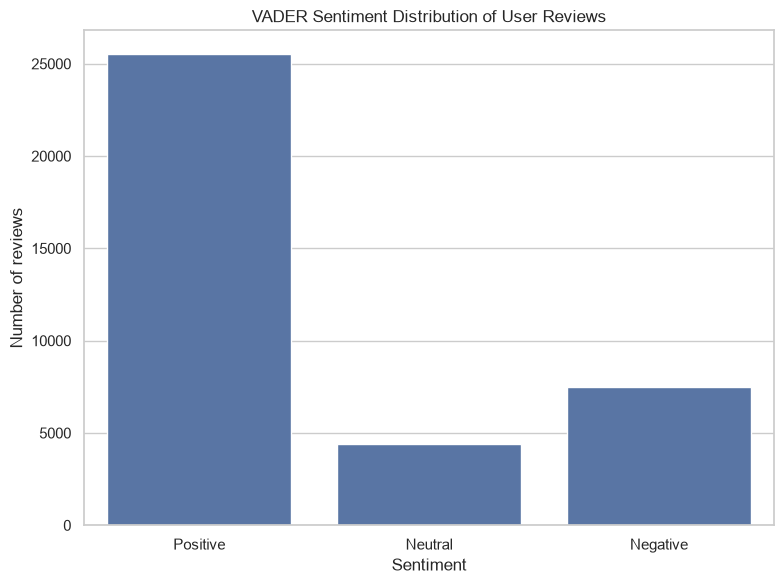

           review_count
sentiment              
Positive          25526
Neutral            4396
Negative           7505
Average VADER compound score: 0.341


In [17]:
# ============================================================
# 7B. Creating a plot to identify score reviews by sentiment
# ============================================================
reviews["vader_compound"] = reviews["Translated_Review"].apply(
    lambda text: sia.polarity_scores(str(text))["compound"]
)

def vader_label(score):
    if score >= 0.05:
        return "Positive"
    if score <= -0.05:
        return "Negative"
    return "Neutral"

reviews["sentiment"] = reviews["vader_compound"].apply(vader_label)

sentiment_counts = reviews["sentiment"].value_counts().reindex(
    ["Positive", "Neutral", "Negative"], fill_value=0
)

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("VADER Sentiment Distribution of User Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

print(sentiment_counts.to_frame("review_count"))
print(f"Average VADER compound score: {reviews['vader_compound'].mean():.3f}")

**Interpretation:** The sentiment mix summarises the emotional direction of the written feedback rather than the star-rating distribution. Positive reviews can reveal product strengths, while negative reviews provide a practical signal of friction points that may affect retention and ratings.

## 8. Sentiment by Category

The review table does not contain category directly, so we map each review to the app metadata and then calculate category-level sentiment. Reviews whose app name cannot be matched are excluded from the category comparison.

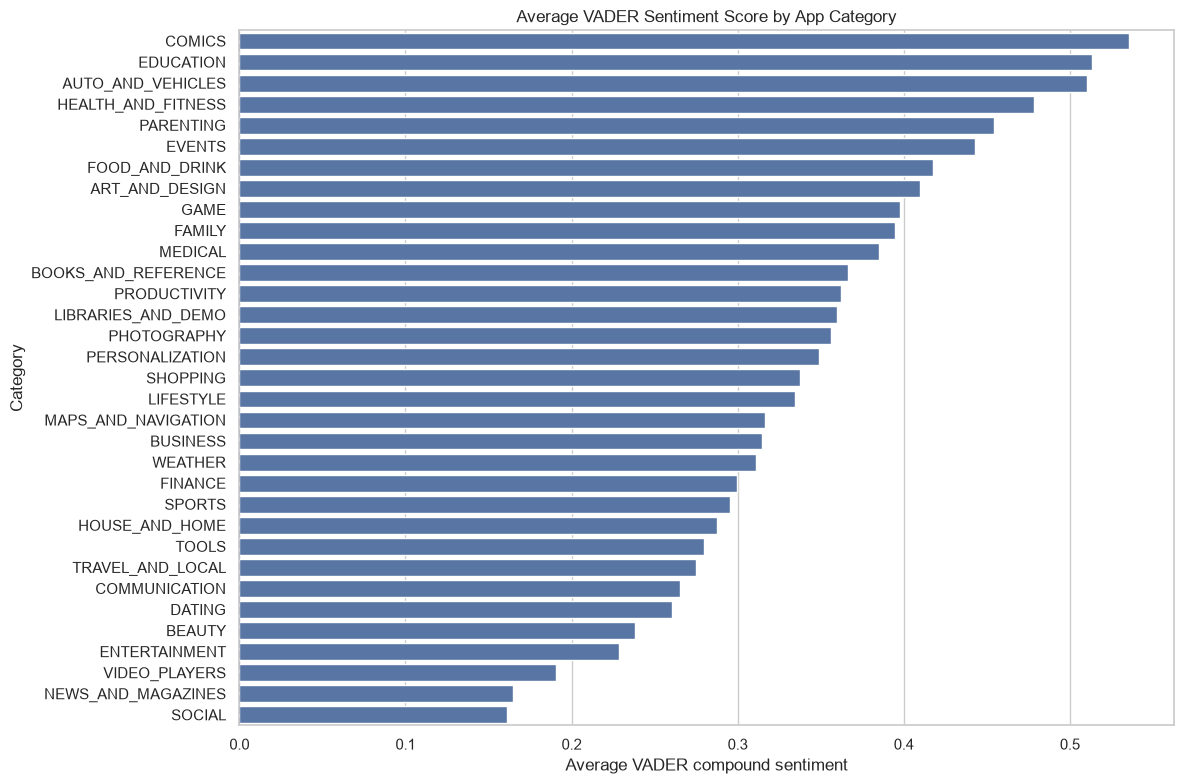

Best sentiment category: COMICS (0.536)
Worst sentiment category: SOCIAL (0.161)


In [18]:
# ============================================================
# 8. Creating a plot to identify reviews with app categories
# ============================================================
review_category = reviews.merge(
    apps[["App", "Category"]],
    on="App",
    how="inner"
)

category_sentiment = (
    review_category.groupby("Category")["vader_compound"]
        .agg(["mean", "count"])
        .query("count >= 10")
        .sort_values("mean", ascending=False)
)

plt.figure(figsize=(12, 8))
sns.barplot(x=category_sentiment["mean"], y=category_sentiment.index)
plt.title("Average VADER Sentiment Score by App Category")
plt.xlabel("Average VADER compound sentiment")
plt.ylabel("Category")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

best_sentiment_category = category_sentiment["mean"].idxmax()
worst_sentiment_category = category_sentiment["mean"].idxmin()

print(
    f"Best sentiment category: {best_sentiment_category} "
    f"({category_sentiment.loc[best_sentiment_category, 'mean']:.3f})"
)
print(
    f"Worst sentiment category: {worst_sentiment_category} "
    f"({category_sentiment.loc[worst_sentiment_category, 'mean']:.3f})"
)

**Interpretation:** Category-level sentiment shows where written feedback is most positive or negative on average. Because the analysis uses a minimum review count, categories with only a handful of reviews are less likely to produce unstable extremes.

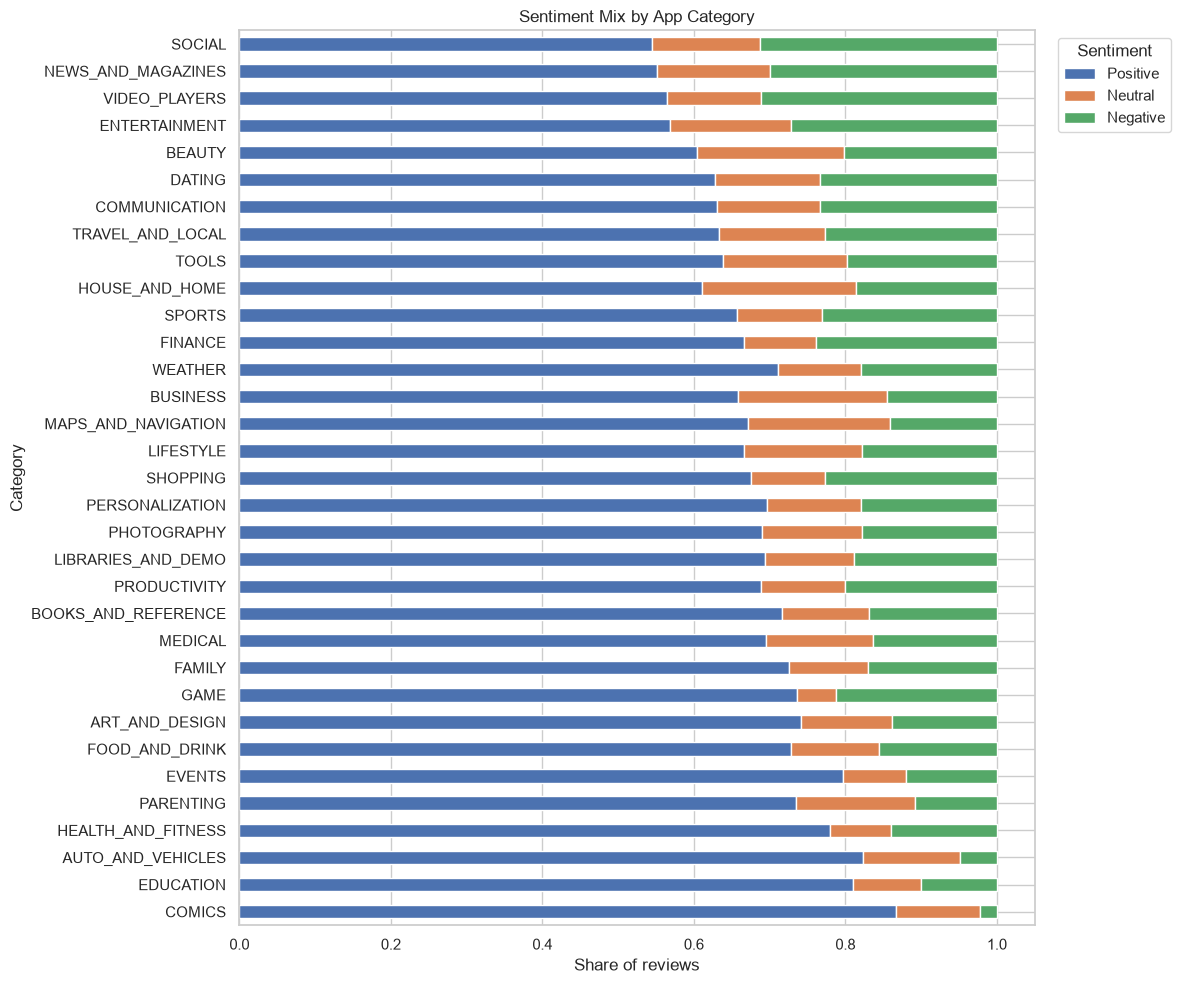

Categories with the highest positive-review share:


,positive_share
Category,
COMICS,0.866667
AUTO_AND_VEHICLES,0.823529
EDUCATION,0.809917
EVENTS,0.797468
HEALTH_AND_FITNESS,0.779458


In [19]:
# ============================================================
# 8B. Creating a plot for to identify sentiment by category
# ============================================================
sentiment_mix = pd.crosstab(
    review_category["Category"],
    review_category["sentiment"],
    normalize="index"
).reindex(columns=["Positive", "Neutral", "Negative"], fill_value=0)

sentiment_mix = sentiment_mix.loc[category_sentiment.index]

ax = sentiment_mix.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 10),
    title="Sentiment Mix by App Category"
)
ax.set_xlabel("Share of reviews")
ax.set_ylabel("Category")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Categories with the highest positive-review share:")
display(sentiment_mix["Positive"].sort_values(ascending=False).head(5).to_frame("positive_share"))

**Interpretation:** The stacked view complements the mean score by showing the composition of feedback. A category can have a respectable mean while still containing a meaningful negative-review segment, which is important for identifying product-quality risks.

## 9. Interactive Visualization

Plotly provides a browser-based interactive view. Hovering reveals category, average rating, installs and app count, while the log-scaled install axis makes small and very large categories visible together.

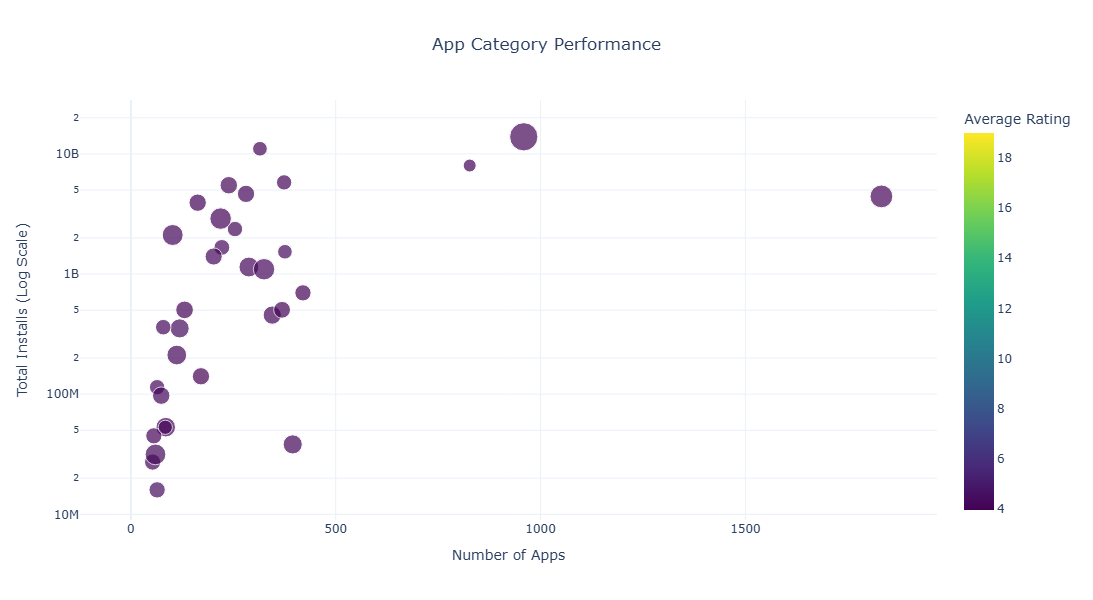

In [20]:
# ============================================================
# 9. Creating an interactive plot for exploring categories
# ============================================================

try:
    import plotly.express as px

    # Creating a summary of each app category
    interactive_category = (
        apps.groupby("Category")
        .agg(
            app_count=("App", "nunique"),
            avg_rating=("Rating", "mean"),
            total_installs=("Installs", "sum"),
            avg_size_mb=("Size_MB", "mean")
        )
        .reset_index()
    )

    # Replacing the missing app-size averages so plotly can size every bubble
    interactive_category["avg_size_mb"] = (
        interactive_category["avg_size_mb"]
        .fillna(apps["Size_MB"].median())
        .clip(lower=0.1)
    )

    # Rounding the ratings to make the interactive display easier to read
    interactive_category["avg_rating"] = interactive_category["avg_rating"].round(2)

    # Creating the interactive scatter plot
    fig = px.scatter(
        interactive_category,
        x="app_count",
        y="total_installs",
        size="avg_size_mb",
        color="avg_rating",
        hover_name="Category",
        hover_data={
            "app_count": ":,",
            "total_installs": ":,",
            "avg_rating": ":.2f",
            "avg_size_mb": ":.1f"
        },
        log_y=True,
        title="App Category Performance",
        labels={
            "app_count": "Number of Apps",
            "total_installs": "Total Installs (Log Scale)",
            "avg_size_mb": "Average App Size (MB)",
            "avg_rating": "Average Rating"
        },
        color_continuous_scale="Viridis"
    )

    fig.update_layout(
        template="plotly_white",
        height=600,
        title_x=0.5,
        xaxis_title="Number of Apps",
        yaxis_title="Total Installs (Log Scale)"
    )
    
    fig.show(config={"displayModeBar": False})

except ImportError:
    print("Plotly is not installed. Run: pip install plotly")

except Exception as e:
    print(f"Could not create Plotly chart: {e}")

**Interpretation:** This interactive chart helps identify categories that combine high market presence with high aggregate reach. It should be read as a market-structure view, not as evidence that a category-level total can be achieved by a single new app.

## 10. Conclusion

The next cell generates exactly three launch-oriented insights from the cleaned data. The numbers are calculated at runtime, so they remain correct whether the notebook uses the real GitHub mirror or the synthetic fallback.

In [21]:
# ============================================================
# 10. Identifying the insights
# ============================================================
# Insight 1: Market Saturation
top_category = category_counts.index[0]
top_category_count = int(category_counts.iloc[0])

# Insight 2: Rating Benchmark
overall_median_rating = float(apps["Rating"].median())
overall_mean_rating = float(apps["Rating"].mean())

# Insight 3: Monetisation + Sentiment
free_share = float((apps["App_Type"] == "Free").mean() * 100)
positive_share = float((reviews["sentiment"] == "Positive").mean() * 100)

print("1. COMPETITION: "
      f"{top_category} is the most saturated category with {top_category_count:,} apps. "
      "A new entrant should have a clear niche or differentiation strategy rather than competing as a generic app.")

print("2. QUALITY: "
      f"The median app rating is {overall_median_rating:.2f}/5 (mean {overall_mean_rating:.2f}/5). "
      "A launch strategy should treat user experience, reliability and review generation as core product metrics because the market already contains many highly rated apps.")

print("3. MONETISATION & FEEDBACK: "
      f"{free_share:.1f}% of analysed apps are free, while {positive_share:.1f}% of usable reviews receive a Positive VADER label. "
      "A developer should benchmark a free/freemium model carefully and use review sentiment to prioritise product improvements rather than relying on price alone.")

1. COMPETITION: FAMILY is the most saturated category with 1,832 apps. A new entrant should have a clear niche or differentiation strategy rather than competing as a generic app.
2. QUALITY: The median app rating is 4.30/5 (mean 4.18/5). A launch strategy should treat user experience, reliability and review generation as core product metrics because the market already contains many highly rated apps.
3. MONETISATION & FEEDBACK: 92.2% of analysed apps are free, while 68.2% of usable reviews receive a Positive VADER label. A developer should benchmark a free/freemium model carefully and use review sentiment to prioritise product improvements rather than relying on price alone.


## Limitations

- The dataset is a historical scraped snapshot rather than a current Google Play Store feed, so market conditions and category composition have changed.
- `Installs` are reported in coarse buckets such as `10,000+`; treating the bucket value as an exact count introduces measurement error.
- Ratings and reviews are observational and can be affected by selection bias, survivorship bias and differences in review volume across apps.
- `Installs × Price` is only a rough revenue-value proxy and is **not actual revenue**.
- VADER is a lexicon-based English sentiment model; sarcasm, multilingual text, slang and domain-specific language can reduce accuracy.
- Missing ratings and sizes are retained as missing rather than imputed, so each metric can have a different effective sample size.
- If the remote mirrors are unavailable, the notebook uses a synthetic fallback. In that case, all numerical findings are illustrative rather than findings from the original Kaggle snapshot.